In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
time_series = pd.read_csv('../data/time_series_60min_singleindex.csv')
time_series["utc_timestamp"] = pd.to_datetime(time_series["utc_timestamp"])
weather = pd.read_csv('../data/weather_data.csv')
weather["utc_timestamp"] = pd.to_datetime(weather["utc_timestamp"])
household = pd.read_csv('../data/household_data_60min_singleindex.csv')
household["utc_timestamp"] = pd.to_datetime(household["utc_timestamp"])

In [52]:
country_code = "DE"

In [122]:
data = time_series[time_series["utc_timestamp"].dt.year.isin(range(2015, 2021))][
    ["utc_timestamp"] + time_series.columns[time_series.columns.str.startswith(country_code)].tolist()
    ].merge(
    weather[["utc_timestamp"] + weather.columns[weather.columns.str.startswith(country_code)].tolist()],
    on="utc_timestamp",
    how="left"
).set_index("utc_timestamp")


In [134]:
data = household[household["utc_timestamp"].dt.year.isin(range(2015, 2018)) & household["DE_KN_residential5_grid_import"].notnull()][
        ["utc_timestamp"] + household.columns[household.columns.str.contains("residential5")].tolist()].merge(
    weather[["utc_timestamp"] + weather.columns[weather.columns.str.startswith(country_code)].tolist()],
    on="utc_timestamp",
    how="left"
).merge(
    time_series[["utc_timestamp"] + time_series.columns[time_series.columns.str.startswith(country_code)].tolist()],
    on="utc_timestamp",
    how="left"
).set_index("utc_timestamp")

In [141]:
print(data.columns.tolist())

['DE_KN_residential5_dishwasher', 'DE_KN_residential5_grid_import', 'DE_KN_residential5_refrigerator', 'DE_KN_residential5_washing_machine', 'DE_temperature', 'DE_radiation_direct_horizontal', 'DE_radiation_diffuse_horizontal', 'DE_load_actual_entsoe_transparency', 'DE_load_forecast_entsoe_transparency', 'DE_solar_capacity', 'DE_solar_generation_actual', 'DE_solar_profile', 'DE_wind_capacity', 'DE_wind_generation_actual', 'DE_wind_profile', 'DE_wind_offshore_capacity', 'DE_wind_offshore_generation_actual', 'DE_wind_offshore_profile', 'DE_wind_onshore_capacity', 'DE_wind_onshore_generation_actual', 'DE_wind_onshore_profile', 'DE_50hertz_load_actual_entsoe_transparency', 'DE_50hertz_load_forecast_entsoe_transparency', 'DE_50hertz_solar_generation_actual', 'DE_50hertz_wind_generation_actual', 'DE_50hertz_wind_offshore_generation_actual', 'DE_50hertz_wind_onshore_generation_actual', 'DE_LU_load_actual_entsoe_transparency', 'DE_LU_load_forecast_entsoe_transparency', 'DE_LU_price_day_ahead',

data.DE

In [135]:
data.head(24)


,DE_KN_residential5_dishwasher,DE_KN_residential5_grid_import,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_temperature,DE_radiation_direct_horizontal,DE_radiation_diffuse_horizontal,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,...,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2015-10-26 11:00:00+00:00,0.000,0.045,0.000,0.000,13.492,288.5490,116.9541,66061.0,66337.0,38393.0,...,21078.0,21763.0,5794.0,2800.0,1021.0,1780.0,9297.0,9121.0,1779.0,48.0
2015-10-26 12:00:00+00:00,0.000,0.395,0.071,0.148,14.209,278.8196,106.5831,64987.0,65392.0,38393.0,...,20700.0,21364.0,5328.0,2683.0,961.0,1722.0,9178.0,9052.0,1751.0,50.0
2015-10-26 13:00:00+00:00,0.000,0.865,0.082,0.488,14.409,220.7485,96.3061,63737.0,64218.0,38393.0,...,20227.0,20996.0,4149.0,2522.0,867.0,1656.0,9032.0,8793.0,1469.0,53.0
2015-10-26 14:00:00+00:00,0.000,1.085,0.126,0.575,14.003,128.5738,82.0546,63108.0,63167.0,38393.0,...,20052.0,20546.0,2327.0,2476.0,847.0,1629.0,8827.0,8660.0,862.0,47.0
2015-10-26 15:00:00+00:00,0.000,1.325,0.184,0.670,12.040,34.1750,50.5976,62540.0,62118.0,38393.0,...,20077.0,20000.0,548.0,2981.0,989.0,1992.0,8622.0,8397.0,208.0,51.0
2015-10-26 16:00:00+00:00,0.001,1.435,0.210,0.674,9.068,0.8030,3.8290,66703.0,63504.0,38393.0,...,21778.0,20098.0,13.0,4381.0,1299.0,3083.0,8990.0,8243.0,0.0,81.0
2015-10-26 17:00:00+00:00,0.001,1.645,0.253,0.674,8.191,0.0000,0.0000,68695.0,64900.0,38393.0,...,22346.0,20580.0,0.0,5474.0,1605.0,3870.0,9226.0,8488.0,0.0,109.0
2015-10-26 18:00:00+00:00,0.001,1.885,0.273,0.674,7.561,0.0000,0.0000,66809.0,64820.0,38393.0,...,21521.0,20633.0,0.0,5820.0,1681.0,4140.0,8944.0,8849.0,0.0,127.0
2015-10-26 19:00:00+00:00,0.351,2.550,0.340,0.674,6.952,0.0000,0.0000,62345.0,61149.0,38393.0,...,19907.0,19342.0,0.0,5725.0,1595.0,4129.0,8389.0,8344.0,0.0,113.0


In [123]:
data.tail(24)

,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,...,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual,DE_temperature,DE_radiation_direct_horizontal,DE_radiation_diffuse_horizontal
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2020-09-30 00:00:00+00:00,44159.0,43023.0,NaN,0.0,NaN,NaN,1491.0,NaN,NaN,405.0,...,619.0,389.0,230.0,5733.0,5342.0,0.0,28.0,NaN,NaN,NaN
2020-09-30 01:00:00+00:00,44415.0,43307.0,NaN,0.0,NaN,NaN,1723.0,NaN,NaN,685.0,...,926.0,671.0,255.0,5799.0,5349.0,0.0,19.0,NaN,NaN,NaN
2020-09-30 02:00:00+00:00,45834.0,44531.0,NaN,0.0,NaN,NaN,1877.0,NaN,NaN,907.0,...,1201.0,902.0,299.0,5950.0,5503.0,0.0,22.0,NaN,NaN,NaN
2020-09-30 03:00:00+00:00,49486.0,47931.0,NaN,0.0,NaN,NaN,2101.0,NaN,NaN,1229.0,...,1578.0,1229.0,350.0,6511.0,6050.0,0.0,15.0,NaN,NaN,NaN
2020-09-30 04:00:00+00:00,57232.0,55754.0,NaN,1.0,NaN,NaN,2439.0,NaN,NaN,1593.0,...,1981.0,1591.0,390.0,7757.0,7377.0,0.0,19.0,NaN,NaN,NaN
2020-09-30 05:00:00+00:00,61960.0,60792.0,NaN,347.0,NaN,NaN,2778.0,NaN,NaN,1893.0,...,2316.0,1892.0,424.0,8623.0,8207.0,29.0,28.0,NaN,NaN,NaN
2020-09-30 06:00:00+00:00,63790.0,63255.0,NaN,2597.0,NaN,NaN,3173.0,NaN,NaN,2132.0,...,2657.0,2131.0,525.0,8998.0,8578.0,346.0,19.0,NaN,NaN,NaN
2020-09-30 07:00:00+00:00,64904.0,63901.0,NaN,6719.0,NaN,NaN,3280.0,NaN,NaN,2257.0,...,2905.0,2256.0,649.0,8956.0,8719.0,1010.0,4.0,NaN,NaN,NaN
2020-09-30 08:00:00+00:00,65475.0,65001.0,NaN,11302.0,NaN,NaN,3537.0,NaN,NaN,2586.0,...,3310.0,2585.0,725.0,9121.0,8996.0,1853.0,2.0,NaN,NaN,NaN


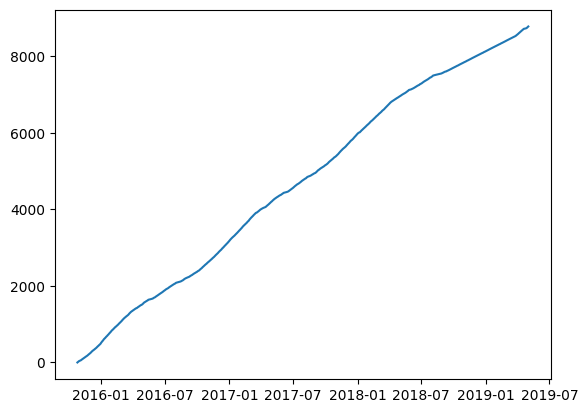

In [88]:
plt.plot(household["utc_timestamp"], household["DE_KN_residential5_grid_import"])
plt.show()

<Axes: xlabel='utc_timestamp'>

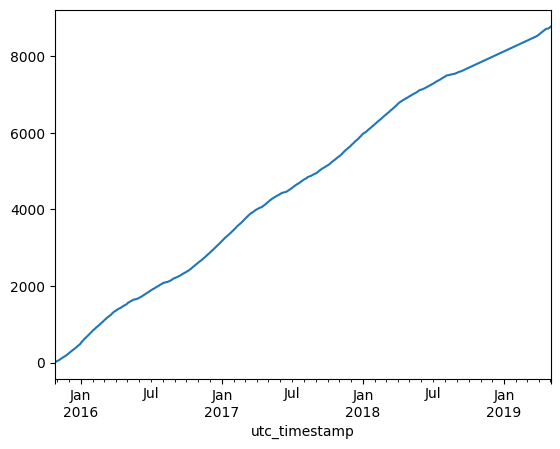

In [89]:
data.DE_KN_residential5_grid_import.plot()


<Axes: xlabel='utc_timestamp'>

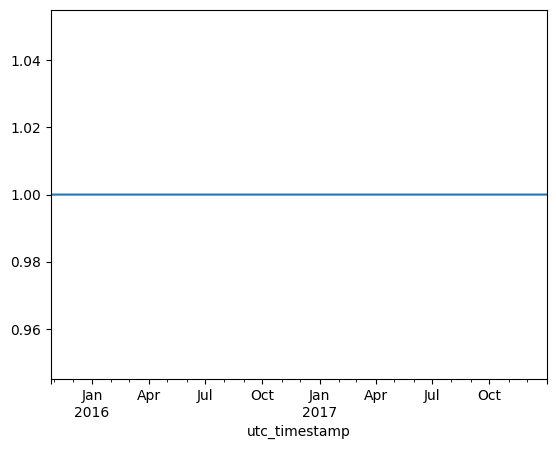

In [137]:
data['DE_LU_price_day_ahead'].isna().astype(int).plot()

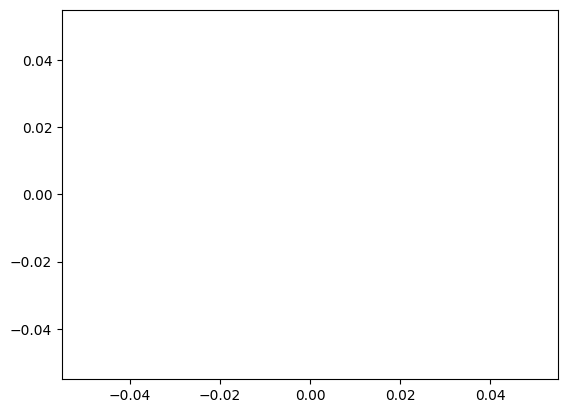

In [139]:
plt.scatter(
    data[data.DE_LU_price_day_ahead.notna()]["DE_KN_residential5_grid_import"],
    data[data.DE_LU_price_day_ahead.notna()]["DE_LU_price_day_ahead"],
    s=1)

In [140]:
data[data.DE_LU_price_day_ahead.notna()]["DE_KN_residential5_grid_import"]

Series([], Name: DE_KN_residential5_grid_import, dtype: float64)

In [128]:
data[data.DE_LU_price_day_ahead.notna()]["DE_LU_price_day_ahead"], [data[data.DE_LU_price_day_ahead.notna()]["DE_load_actual_entsoe_transparency"]]

(utc_timestamp
 2018-09-30 23:00:00+00:00    56.10
 2018-10-01 00:00:00+00:00    51.41
 2018-10-01 01:00:00+00:00    47.38
 2018-10-01 02:00:00+00:00    47.59
 2018-10-01 03:00:00+00:00    51.61
                              ...  
 2020-09-30 18:00:00+00:00    55.34
 2020-09-30 19:00:00+00:00    49.92
 2020-09-30 20:00:00+00:00    42.79
 2020-09-30 21:00:00+00:00    35.02
 2020-09-30 22:00:00+00:00    34.40
 Name: DE_LU_price_day_ahead, Length: 17540, dtype: float64,
 [utc_timestamp
  2018-09-30 23:00:00+00:00    42126.0
  2018-10-01 00:00:00+00:00    41500.0
  2018-10-01 01:00:00+00:00    42353.0
  2018-10-01 02:00:00+00:00    43802.0
  2018-10-01 03:00:00+00:00    48065.0
                                ...   
  2020-09-30 18:00:00+00:00    61177.0
  2020-09-30 19:00:00+00:00    57559.0
  2020-09-30 20:00:00+00:00    54108.0
  2020-09-30 21:00:00+00:00    49845.0
  2020-09-30 22:00:00+00:00    46886.0
  Name: DE_load_actual_entsoe_transparency, Length: 17540, dtype: float64])